# Youtube Trending Videos Analysis

In [2]:
import pandas as pd
df=pd.read_csv('CAvideos.csv')

### Category Mapping

In [ ]:
# Category mapping
category_mapping = {
    1: "Film & Animation",
    2: "Autos & Vehicles",
    10: "Music",
    15: "Pets & Animals",
    17: "Sports",
    19: "Travel & Events",
    20: "Gaming",
    22: "People & Blogs",
    23: "Comedy",
    24: "Entertainment",
    25: "News & Politics",
    26: "Howto & Style",
    27: "Education",
    28: "Science & Technology",
    29: "Nonprofits & Activism"
}

# Add a new column with category names
df["category_name"] = df["category_id"].map(category_mapping)

# Preview
print(df[["category_id", "category_name"]].head())


   category_id  category_name
0           10          Music
1           23         Comedy
2           23         Comedy
3           24  Entertainment
4           10          Music


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np

### 1.Distribution of views, likes, dislikes, comments

c:\Users\arvin\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


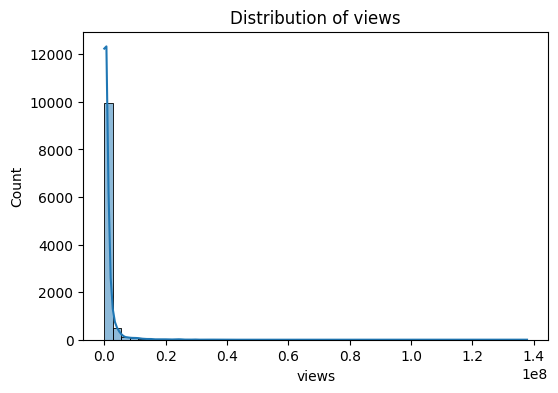

c:\Users\arvin\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


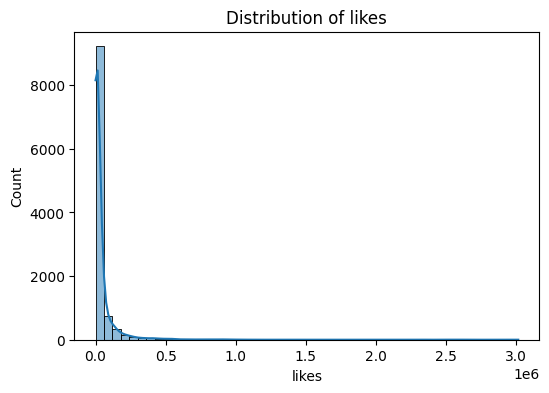

c:\Users\arvin\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


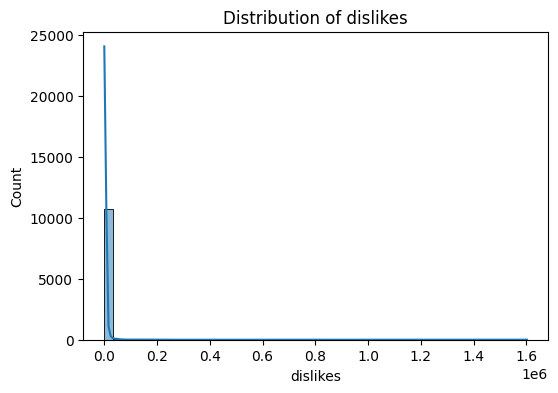

c:\Users\arvin\AppData\Local\Programs\Python\Python39\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


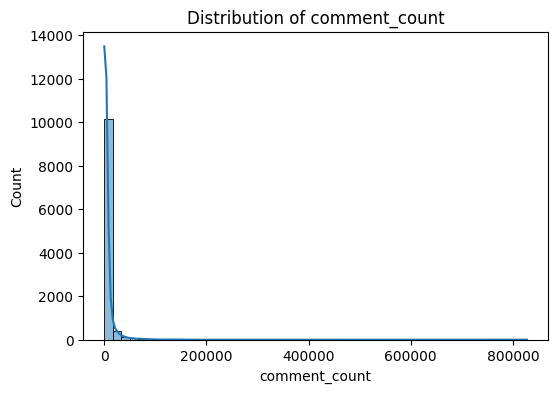

In [ ]:

metrics = ["views", "likes", "dislikes", "comment_count"]

for col in metrics:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


### 2.Categories with most trending videos

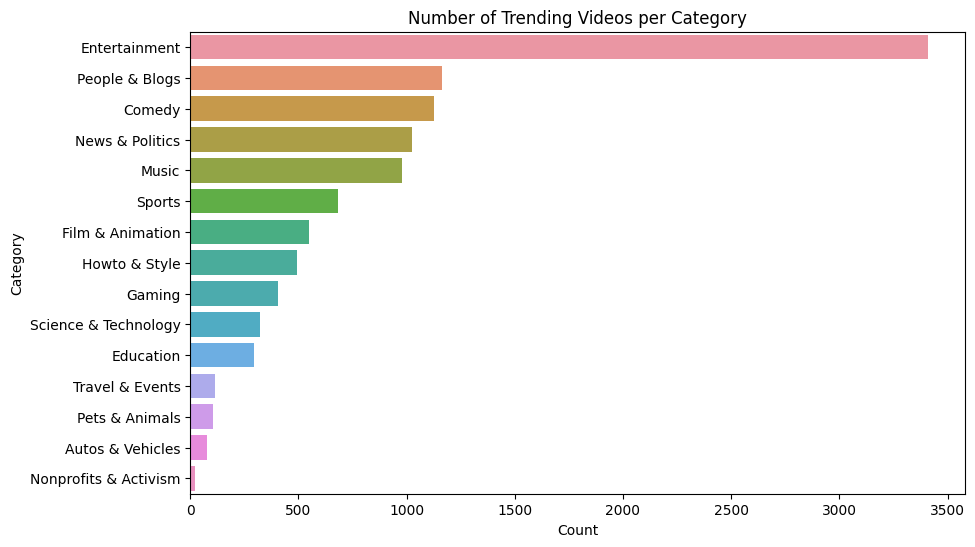

In [ ]:

plt.figure(figsize=(10,6))
sns.countplot(y="category_name", data=df, order=df["category_name"].value_counts().index)
plt.title("Number of Trending Videos per Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

### 3.Category with highest average views

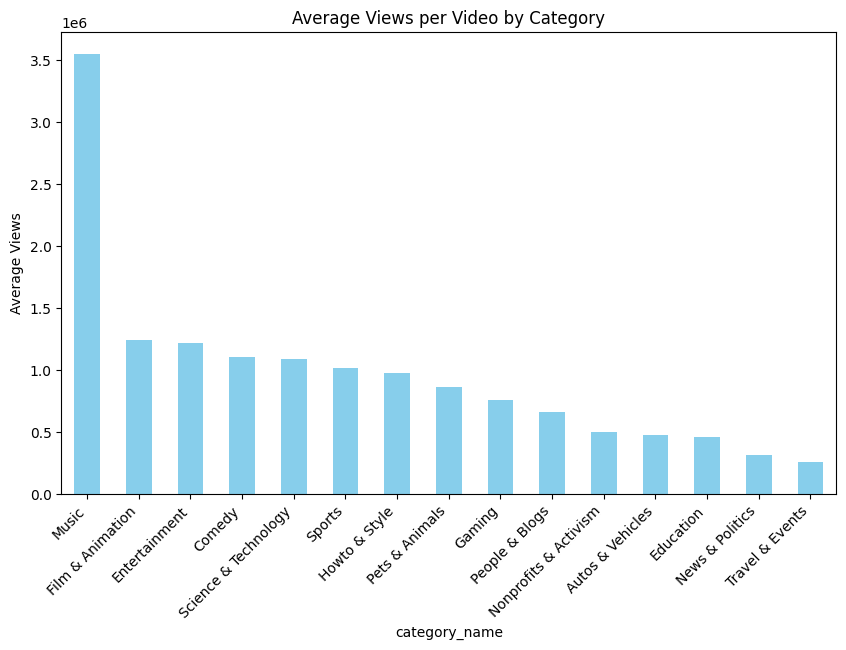

In [ ]:

avg_views = df.groupby("category_name")["views"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
avg_views.plot(kind="bar", color="skyblue")
plt.title("Average Views per Video by Category")
plt.ylabel("Average Views")
plt.xticks(rotation=45, ha="right")
plt.show()

### 4.Correlation between views, likes, dislikes, comments

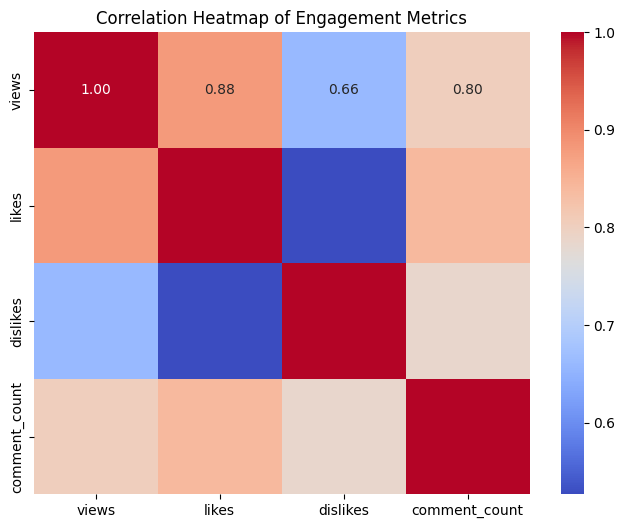

In [ ]:

plt.figure(figsize=(8,6))
sns.heatmap(df[["views","likes","dislikes","comment_count"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Engagement Metrics")
plt.show()

### 5.Which months have most trending videos

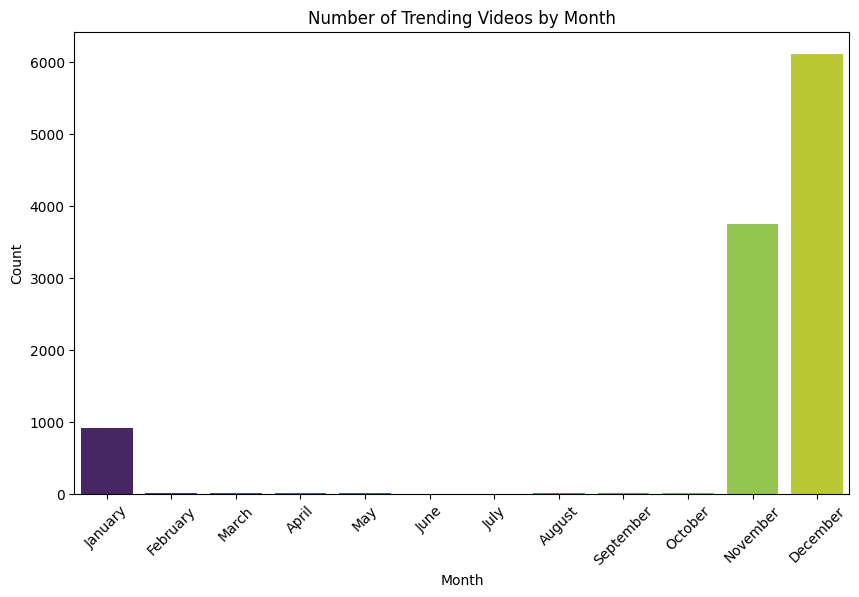

In [ ]:

df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df["month_name"] = df["publish_time"].dt.month_name()

plt.figure(figsize=(10,6))
sns.countplot(x="month_name", data=df,
              order=["January","February","March","April","May","June",
                     "July","August","September","October","November","December"],
              palette="viridis")
plt.title("Number of Trending Videos by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### 6.Day of week videos trend

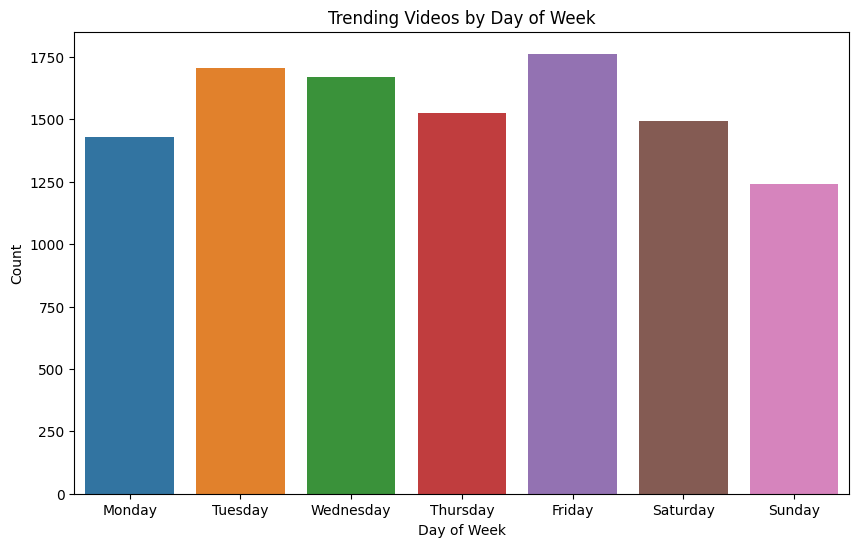

In [ ]:

df["day_of_week"] = df["publish_time"].dt.day_name()

plt.figure(figsize=(10,6))
sns.countplot(x="day_of_week", data=df,
              order=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
plt.title("Trending Videos by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

### 7.Top 10 channels in trending list

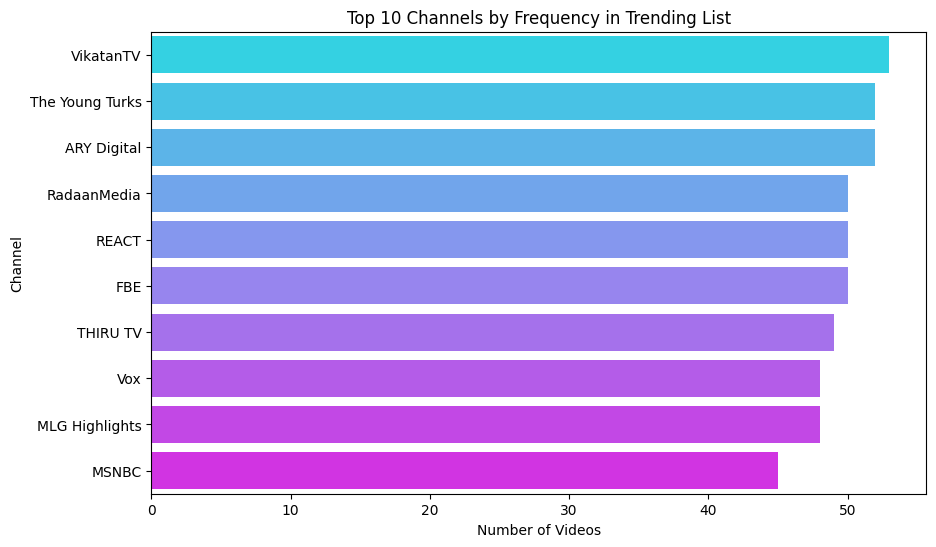

In [ ]:

top_channels = df["channel_title"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_channels.values, y=top_channels.index, palette="cool")
plt.title("Top 10 Channels by Frequency in Trending List")
plt.xlabel("Number of Videos")
plt.ylabel("Channel")
plt.show()

### 8.What is the relationship between title length and views?

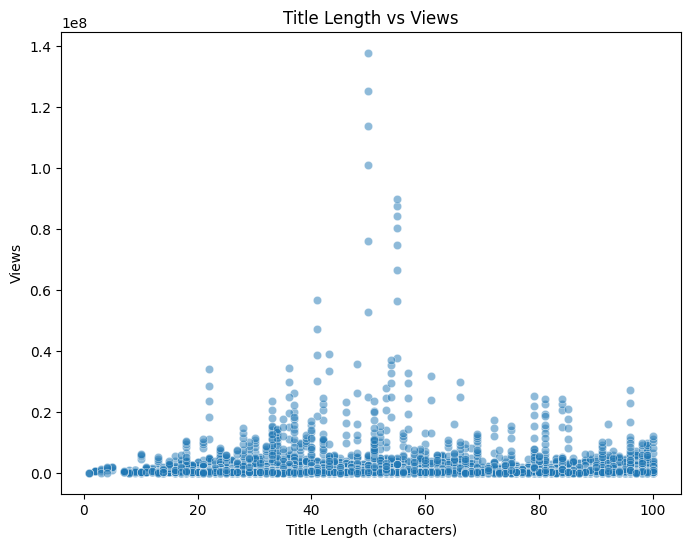

In [ ]:

df["title_length"] = df["title"].apply(lambda x: len(str(x)))
plt.figure(figsize=(8,6))
sns.scatterplot(x="title_length", y="views", data=df, alpha=0.5)
plt.title("Title Length vs Views")
plt.xlabel("Title Length (characters)")
plt.ylabel("Views")
plt.show()

### 9.Which videos gained the highest number of comments relative to views?

                                                   title       channel_title  \
9653    Why I'm Deleting SkyDoesMinecraft (Midnight HST)   Sky Did Minecraft   
2323    My $2500 iPhone X Setup! + NEW iPhone X Giveaway  EverythingApplePro   
9818    Why I'm Deleting SkyDoesMinecraft (Midnight HST)                Adam   
5589   KATHLEENLIGHTS x COLOURPOP DREAM COLLAB HONEST...           Manny Mua   
4936                    FULL FACE USING 7-ELEVEN MAKEUP!           Manny Mua   
4083            My 5 MINUTE Everyday Hair Routine + Tips     Whitney Simmons   
4294            My 5 MINUTE Everyday Hair Routine + Tips     Whitney Simmons   
10212                                  Where I have been             SSundee   
4260   FULL FACE USING PRODUCTS BEAUTY GURUS MADE ME ...           Manny Mua   
5188                          Diverging a New Let's Play       chuggaaconroy   

        views  comment_count  comment_view_ratio  
9653   193053          58011            0.300493  
2323   199971    

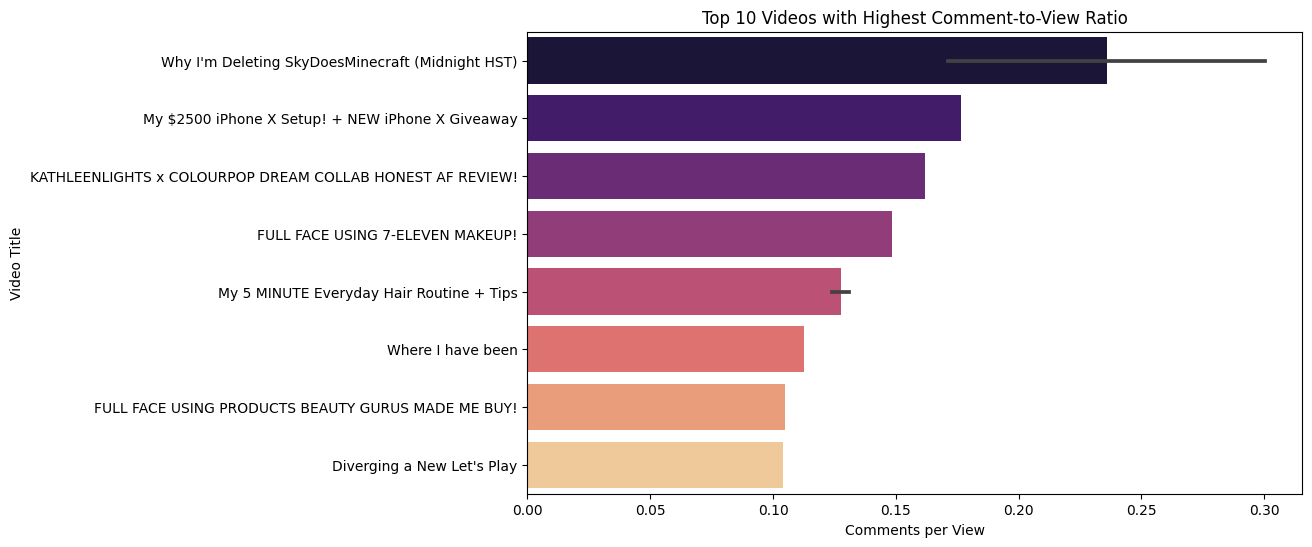

In [ ]:

#(Measures engagement beyond just likes)

df["comment_view_ratio"] = df["comment_count"] / df["views"]
top_commented = df.sort_values("comment_view_ratio", ascending=False).head(10)

print(top_commented[["title", "channel_title", "views", "comment_count", "comment_view_ratio"]])

plt.figure(figsize=(10,6))
sns.barplot(x="comment_view_ratio", y="title", data=top_commented, palette="magma")
plt.title("Top 10 Videos with Highest Comment-to-View Ratio")
plt.xlabel("Comments per View")
plt.ylabel("Video Title")
plt.show()

### 10.Which words are most common in trending video tags?

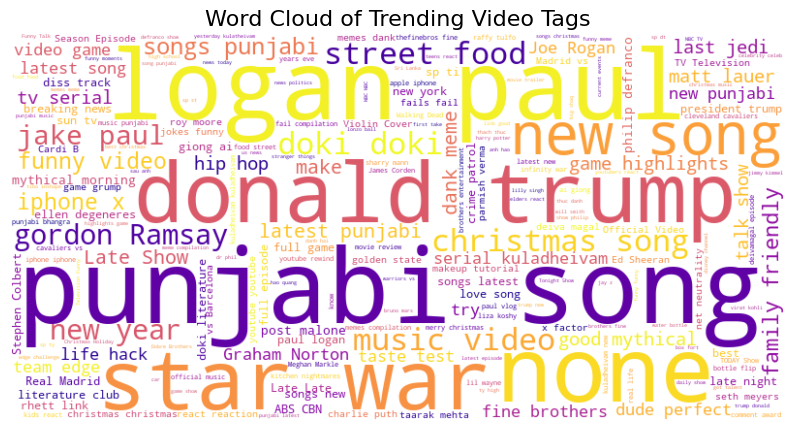

In [ ]:
#(Another word cloud, but from tags instead of titles)
# Replace separators like "|"
tags_text = " ".join(df["tags"].astype(str).str.replace("|", " ", regex=False))
wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="plasma").generate(tags_text)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Trending Video Tags", fontsize=16)
plt.show()